Métodos de Clustering

---



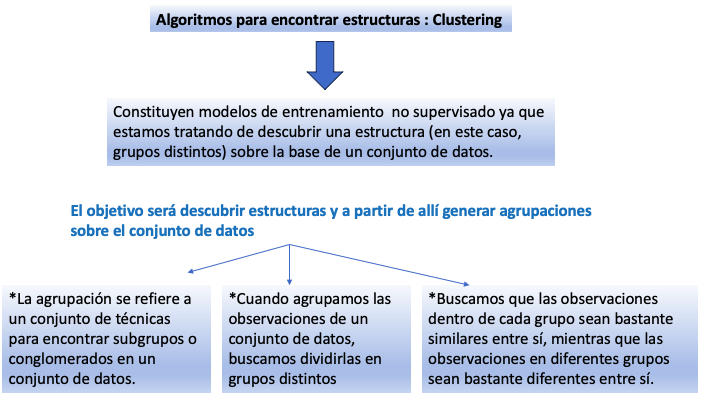

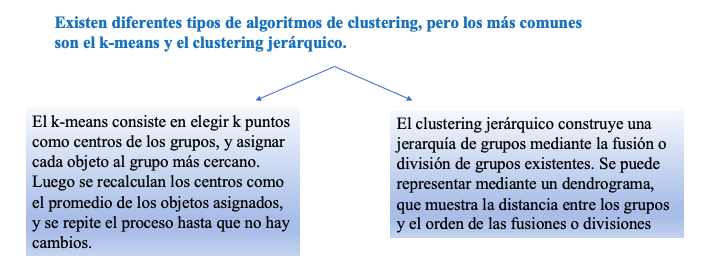

Planteo del problema

---



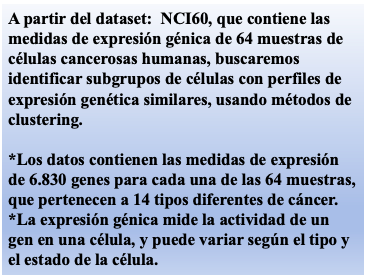

Paso 1 - instalamos e importamos los paquetes y librerías que vamos a usar

Importamos librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


Importamos librerías específicas útiles para el análisis de clustering

In [ ]:
from sklearn.cluster import KMeans
#Importa la clase KMeans del módulo cluster de la biblioteca sklearn.
#KMeans es un algoritmo de clustering que divide un conjunto de datos en K grupos distintos y no superpuestos
from sklearn.cluster import AgglomerativeClustering
#Importa la clase AgglomerativeClustering del módulo cluster de la biblioteca sklearn.
#AgglomerativeClustering es un algoritmo de clustering jerárquico que fusiona los clusters más cercanos en cada paso.
from scipy.cluster.hierarchy import dendrogram
#Importa la función dendrogram del módulo hierarchy de la biblioteca scipy.
#se utiliza para visualizar un dendrograma, que es una representación gráfica de un clustering jerárquico
from scipy.cluster.hierarchy import cut_tree
#Importa la función cut_tree del módulo hierarchy de la biblioteca scipy.
#se utiliza para cortar un dendrograma a un nivel determinado y obtener una partición de los datos


Importamos el conjunto de datos NCI60

In [ ]:
#cargamos el conjunto de datos utilizando la función load_data del módulo ISLP.
#extraemos las etiquetas y los datos del dataset
#y los almacenamos en las variables nci_labs y nci_data.

# Descargar el conjunto de datos NCI60 utilizando get_rdataset
nci_data = get_rdataset("NCI60", "ISLR").data
nci_labs = nci_data['labs']
nci_data = nci_data.drop('labs', axis=1)

In [ ]:
#evaluamos la dimensión
nci_data.shape

(64, 6830)

Inspeccionamos los tipos de cáncer de las líneas celulares

In [ ]:
#contamos la cantidad de veces que cada etiqueta única aparece en nci_labs
nci_labs.value_counts()

,count
labs,
RENAL,9
NSCLC,9
MELANOMA,8
BREAST,7
COLON,7
OVARIAN,6
LEUKEMIA,6
CNS,5
PROSTATE,2


Preparamos y transformamos los datos previo al análisis

In [ ]:
#estandarizamos y escalamos los datos
scaler = StandardScaler()
#ajustamos el escalador a los datos y luego los transformamos
#El método fit_transform() primero ajusta el modelo a los datos (calcula la media y la desviación estándar)
#luego transforma los datos(resta la media y divide por la desviación estándar)
#Los datos transformados se almacenan en nci_scaled.
nci_scaled = scaler.fit_transform(nci_data)
#Aplicamos PCA y reducimos la dimensionalidad
nci_pca = PCA()
nci_scores = nci_pca.fit_transform(nci_scaled)

Creamos dos gráficos de dispersión de los datos transformados por PCA, coloreando los puntos según el tipo de cáncer.

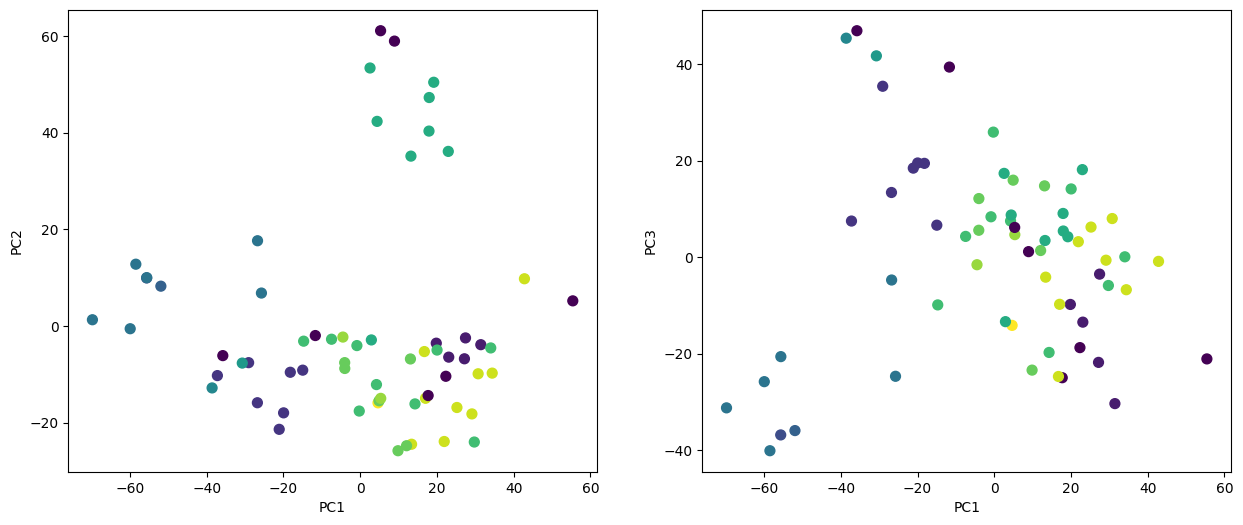

In [ ]:
cancer_types = list(np.unique(nci_labs)) #crea una lista de los tipos únicos de cáncer
nci_groups = np.array([cancer_types.index(lab)
                       for lab in nci_labs.values])
#asigna a cada muestra un número correspondiente a su tipo de cáncer, creando un array de grupos.
fig, axes = plt.subplots(1, 2, figsize=(15,6))
ax = axes[0]
ax.scatter(nci_scores[:,0],
           nci_scores[:,1],
           c=nci_groups ,
           marker='o',
           s=50)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax = axes[1]
ax.scatter(nci_scores[:,0],
           nci_scores[:,2],
           c=nci_groups ,
           marker='o',
           s=50)
ax.set_xlabel('PC1'); ax.set_ylabel('PC3');

Graficamos varianza explicada y varianza explicada acumulada

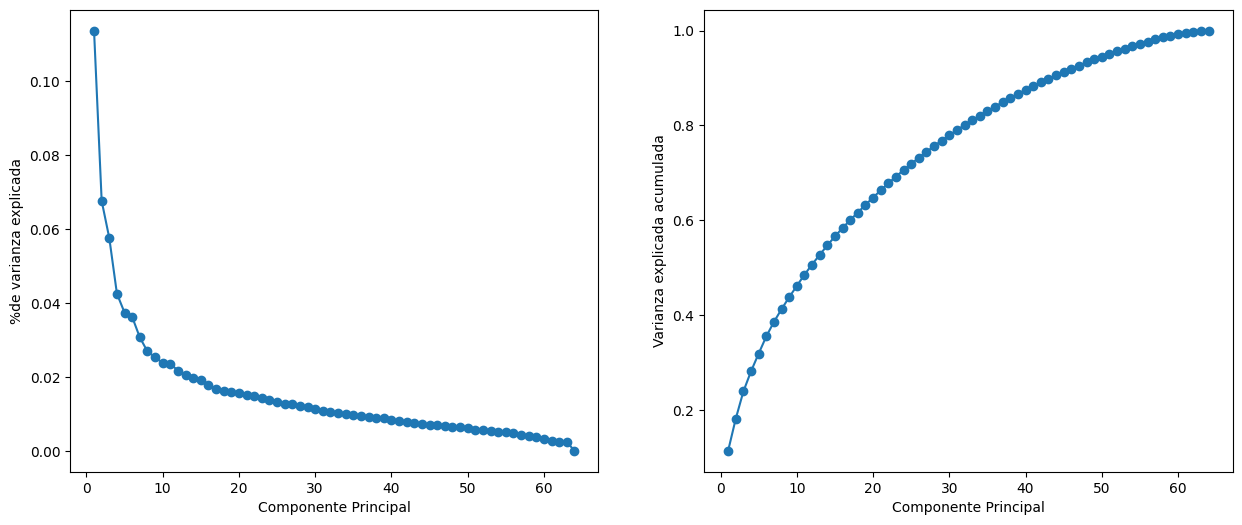

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))
ax = axes[0]
ticks = np.arange(nci_pca.n_components_)+1
ax.plot(ticks,
        nci_pca.explained_variance_ratio_ ,
        marker='o')
ax.set_xlabel('Componente Principal');
ax.set_ylabel('%de varianza explicada')
ax = axes[1]
ax.plot(ticks,
        nci_pca.explained_variance_ratio_.cumsum(),
        marker='o');
ax.set_xlabel('Componente Principal')
ax.set_ylabel('Varianza explicada acumulada');


 *Los primeros siete componentes principales explican alrededor del 40% de la varianza en los datos.

 *El gráfico de la varianza explicada por cada componente principal muestra un marcado descenso después del séptimo componente principal.

Clustering Jerárquico

---

*Agrupamos objetos similares en base a su distancia.

*Se construye una jerarquía de clusters mediante la fusión o división de grupos existentes. Se puede representar mediante un dendrograma, que muestra la distancia entre los grupos y el orden de las fusiones o divisiones.

*En un dendrograma, cada hoja representa una observación. A medida que subimos en el árbol, algunas hojas comienzan a fusionarse en ramas, lo que corresponde a observaciones que son similares entre sí. Las fusiones que ocurren antes (más abajo en el árbol) indican que los grupos de observaciones son muy similares entre sí. Por otro lado, las observaciones que se fusionan más tarde (cerca de la parte superior del árbol) pueden ser bastante diferentes. Para cualquier par de observaciones, podemos buscar el punto en el árbol donde las ramas que contienen esas dos observaciones se fusionan por primera vez.

*El clustering jerárquico aglomerativo comienza con cada observación como un cluster individual y luego las va fusionando según su proximidad.

*Para realizar el clustering jerárquico, se necesita definir una medida de disimilitud o distancia entre las observaciones o los clusters. Existen varias opciones, seleccionamos la distancia euclídea.

*Se necesita definir un criterio de enlace para determinar cómo se fusionan o se dividen los clusters. Existen varios criterios, como el enlace completo, el enlace simple, el enlace promedio, etc. El criterio de enlace puede afectar el resultado del clustering.

*Una vez construido el dendrograma, se puede elegir el número de clusters cortando el árbol a un nivel determinado. Esto implica seleccionar un umbral de disimilitud que defina cuándo dos clusters son suficientemente distintos como para no fusionarse o dividirse.

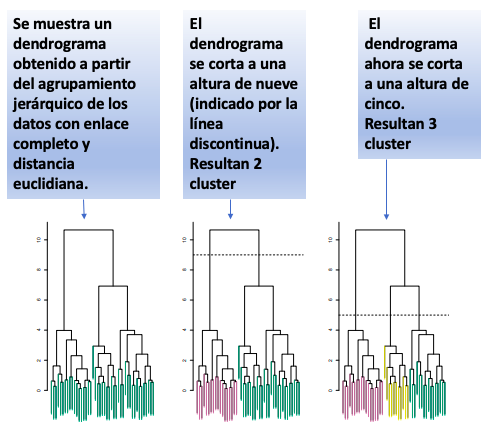

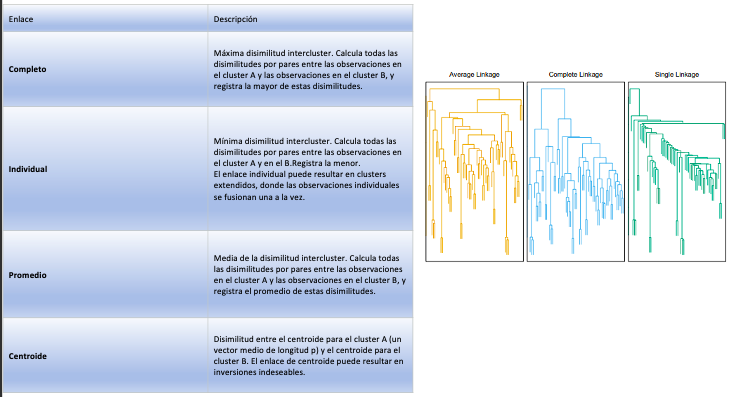

Realizamos el Clustering a partir del conjunto de datos

---

Armamos dendogramas con enlace completo, único y promedio

Usamos la distancia euclidiana como medida de disimilitud

In [ ]:
#asignamos la clase AgglomerativeClustering a la variable HClust.
HClust = AgglomerativeClustering

In [ ]:
from scipy.cluster.hierarchy import linkage

def plot_nci(linkage_method, ax, cut=-np.inf):
    cargs = {'above_threshold_color':'black',
             'color_threshold':cut}

    linkage_matrix = linkage(nci_scaled, method=linkage_method.lower())

    dendrogram(linkage_matrix,
               ax=ax,
               labels=np.asarray(nci_labs),
               leaf_font_size=10,
               **cargs)
    ax.set_title('%s Linkage' % linkage_method)

    hc = AgglomerativeClustering(n_clusters=None,
                                 distance_threshold=0,
                                 linkage=linkage_method.lower()).fit(nci_scaled)
    return linkage_matrix, hc

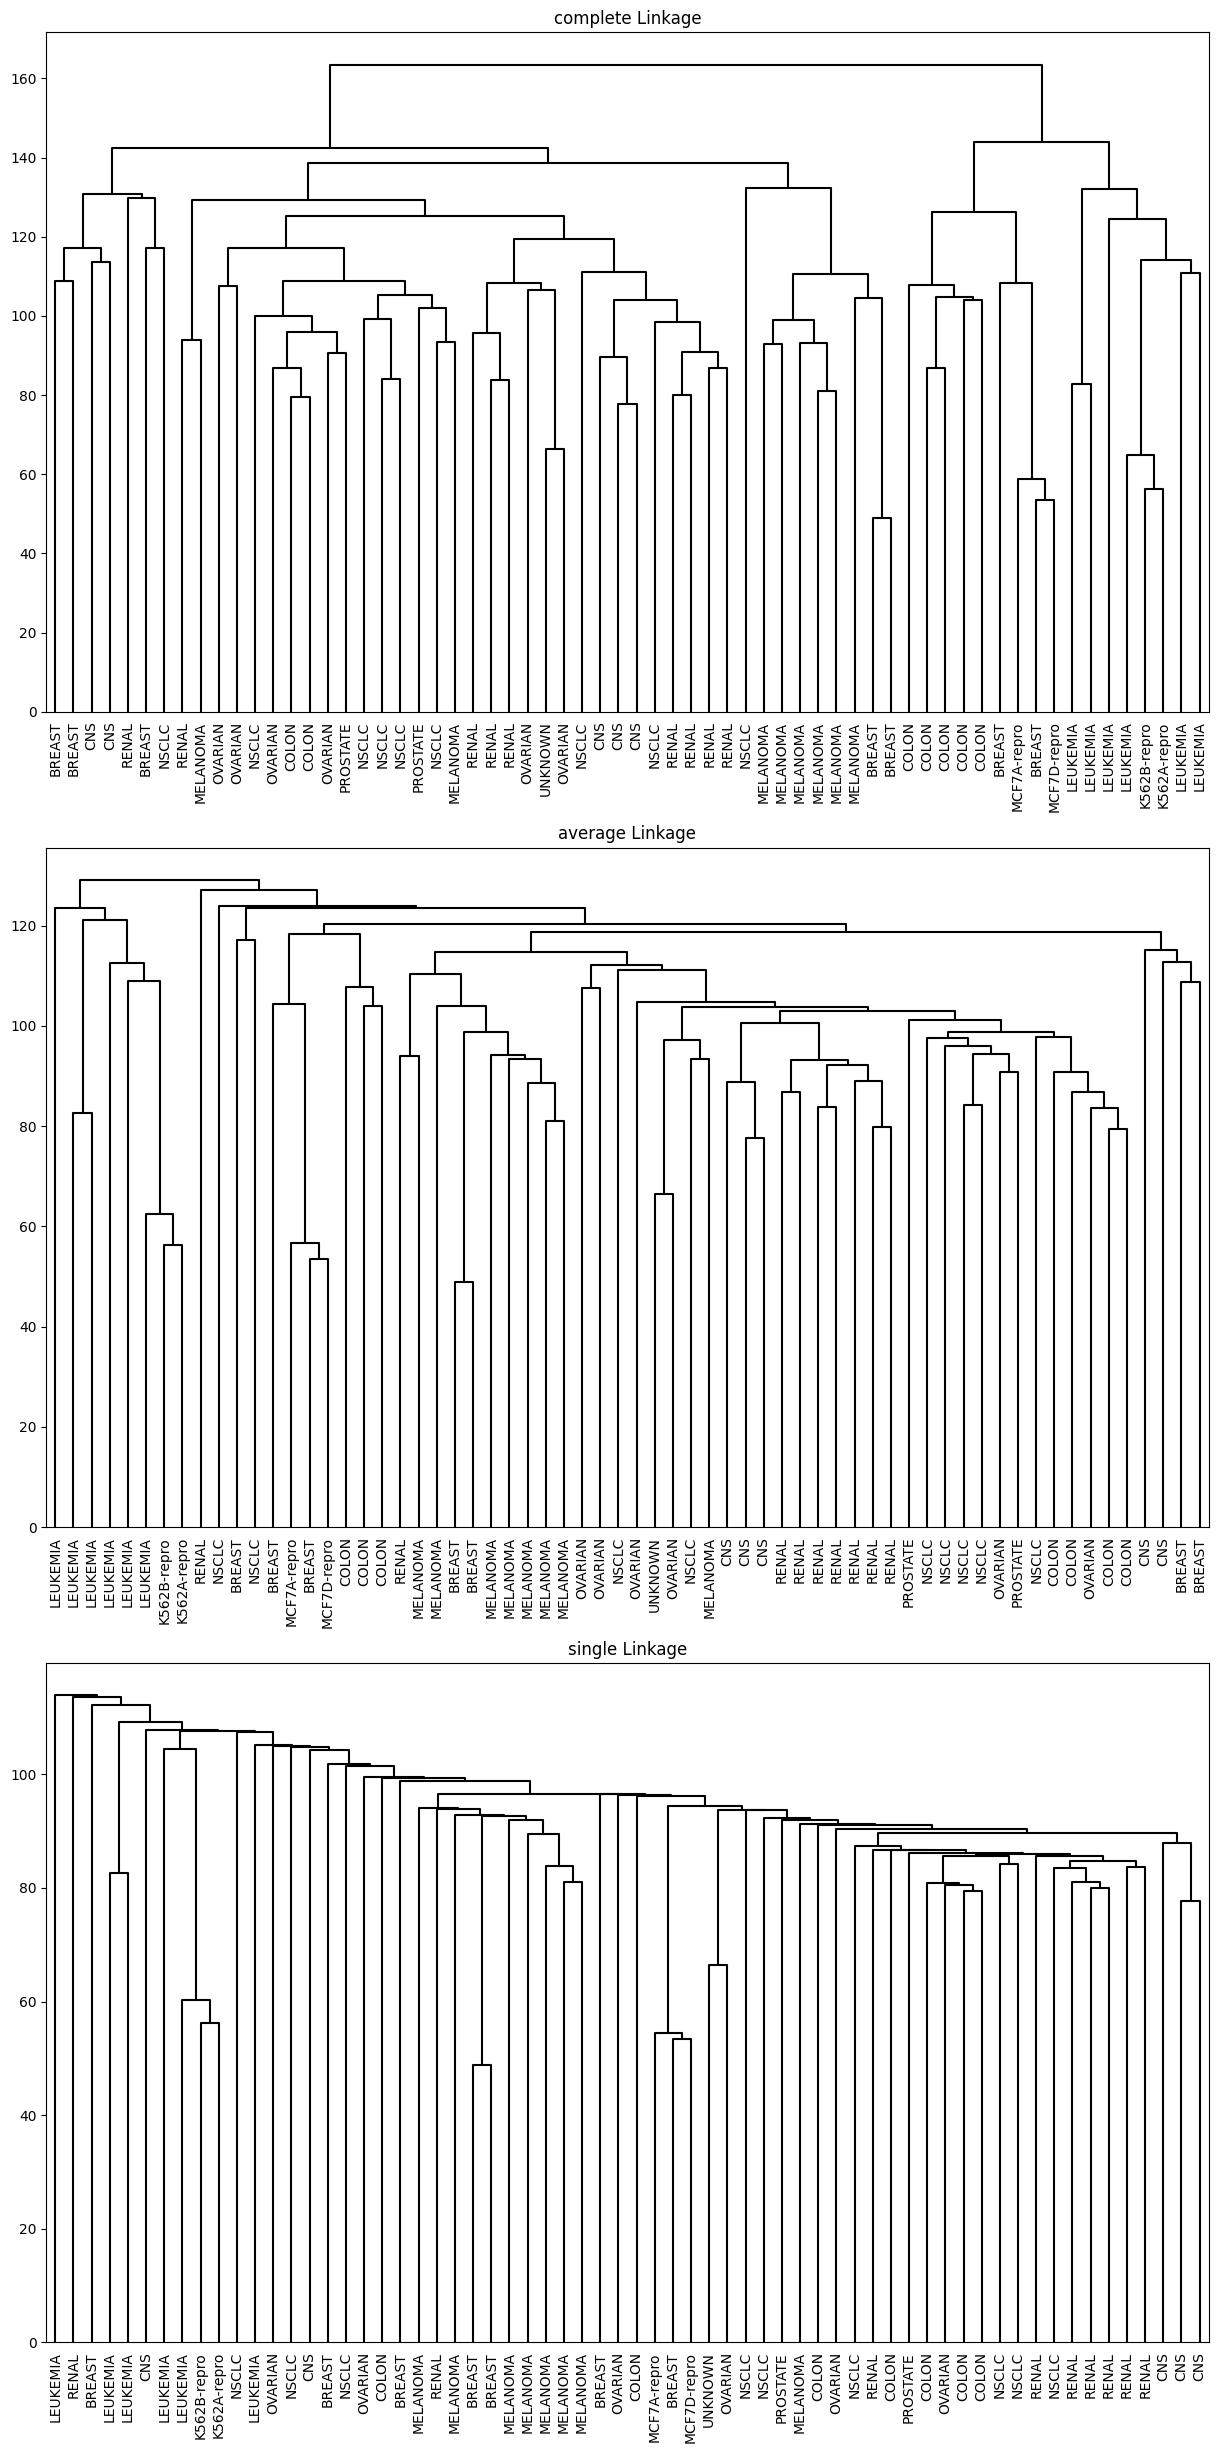

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(15,30))
ax = axes[0]; hc_comp = plot_nci('complete', ax)
ax = axes[1]; hc_avg = plot_nci('average', ax)
ax = axes[2]; hc_sing = plot_nci('single', ax)

Realizamos un agrupamiento jerárquico utilizando un método de enlace completo y luego cortaremos el dendrograma para obtener cuatro clusters. Finalmente, compararemos los clusters obtenidos con las etiquetas originales

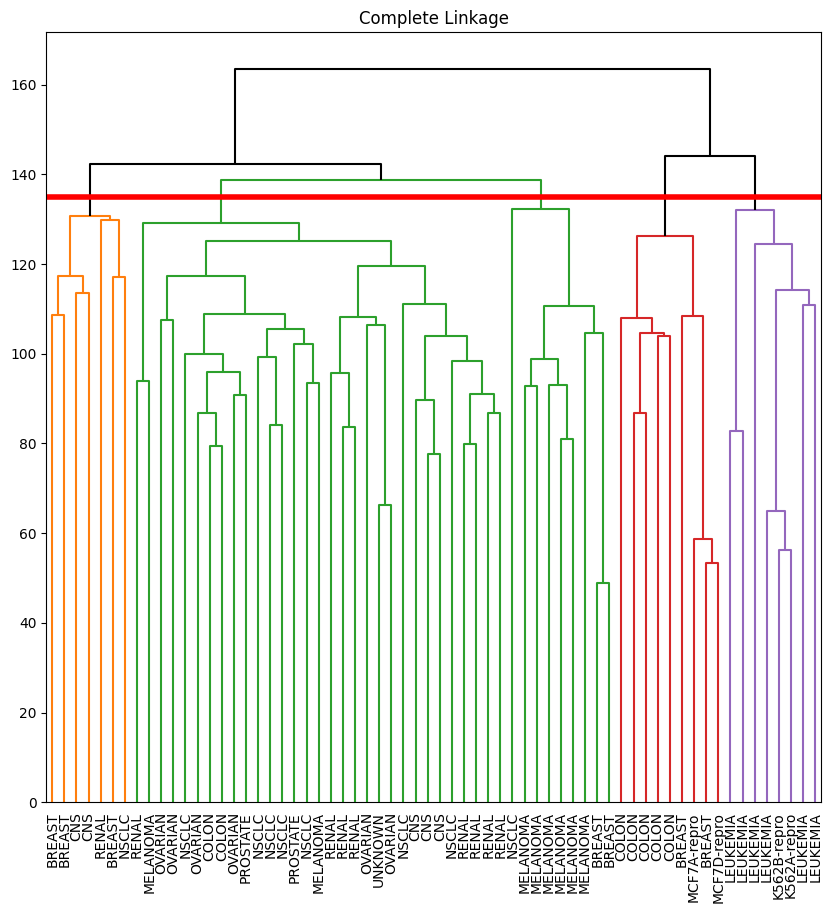

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
plot_nci('Complete', ax, cut=140)
ax.axhline(135, c='r', linewidth=4);


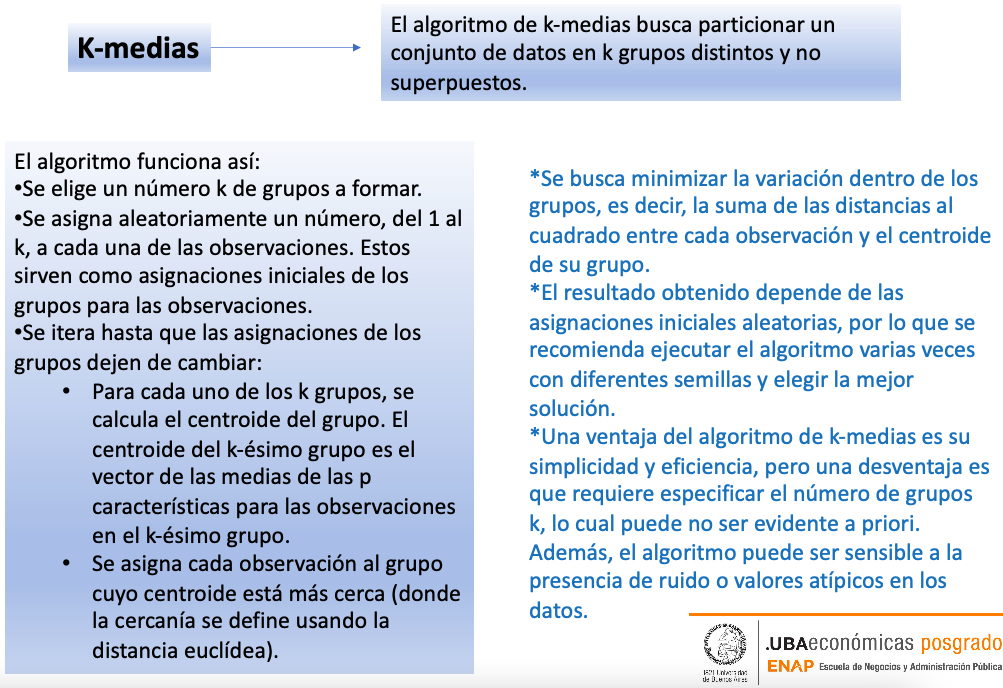

In [ ]:
#ajustamos un modelo K-means a los datos
nci_kmeans = KMeans(n_clusters=4,
                    random_state=0,
                    n_init=20).fit(nci_scaled)
#iniciamos un objeto KMeans con 4 grupos (n_clusters=4)
#random_state=0 asegura que los resultados sean reproducibles
#n_init=20 significa que el algoritmo se ejecutará 20 veces con diferentes centroides iniciales
#el resultado final será el mejor de estas 20 ejecuciones.
#.fit(nci_scaled)ajusta el modelo KMeans a los datos nci_scaled

#creamos una tabla de contingencia
#comparamos los resultados del agrupamiento jerárquico (HClust) y K-means.

comp_cut_new = cut_tree(hc_comp[0], n_clusters=4).reshape(-1)

print("Tabla de contingencia entre HClust y K-means:")
display(pd.crosstab(pd.Series(comp_cut_new, name='HClust'),
            pd.Series(nci_kmeans.labels_, name='K-means')))



#crea la tabla de contingencia entre las etiquetas de agrupamiento jerárquico (comp_cut)
#y las etiquetas de K-means (nci_kmeans.labels_).
#Cada fila de la tabla corresponde a un grupo del agrupamiento jerárquico,
#cada columna corresponde a un grupo del K-means.
#El valor en una celda específica indica
#cuántos puntos de datos en ese grupo de agrupamiento jerárquico están también en ese grupo de K-means.

Tabla de contingencia entre HClust y K-means:


K-means,0,1,2,3
HClust,,,,
0,1,20,10,9
1,0,7,0,0
2,8,0,0,0
3,0,0,9,0


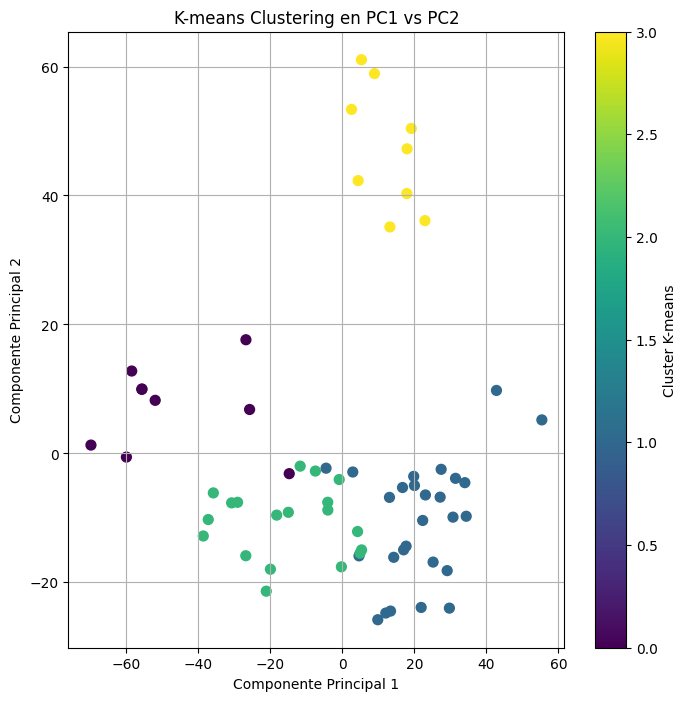

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(nci_scores[:, 0], nci_scores[:, 1], c=nci_kmeans.labels_, cmap='viridis', marker='o', s=50)
plt.title('K-means Clustering en PC1 vs PC2')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(label='Cluster K-means')
plt.grid(True)
plt.show()

In [ ]:
#armamos un diccionario
cargs = {'color_threshold':-np.inf,#establece el umbral de color en menos infinito
         'above_threshold_color':'black'}#establece el color de los grupos que están por encima del umbral en negro

Complete-PCA
labs


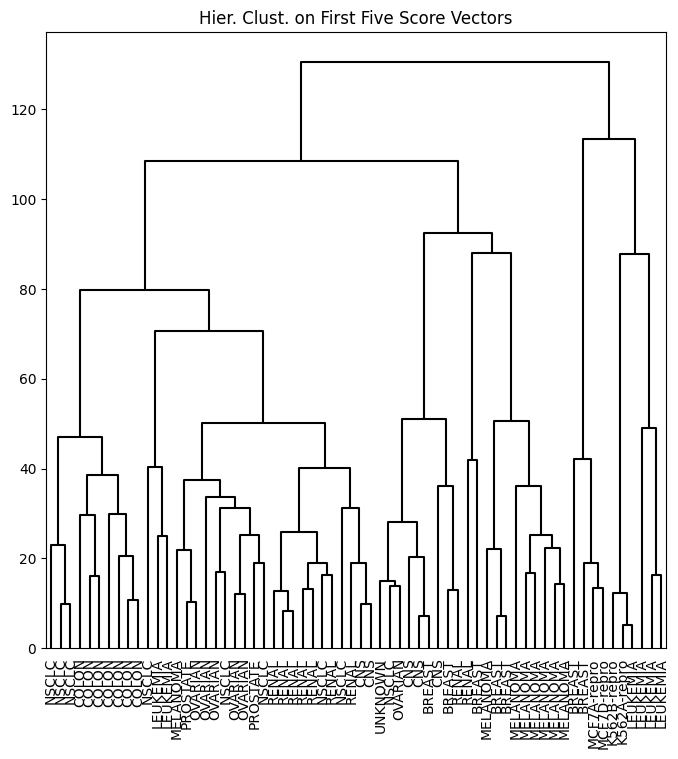

In [ ]:
#inicializamos un objeto HClust con el método de enlace completo (linkage='complete').
#el número de grupos no está predefinido y
#el agrupamiento se realiza hasta que todas las distancias entre grupos sean mayores que 0.
hc_pca = HClust(n_clusters=None,
                distance_threshold=0,
                linkage='complete'
                ).fit(nci_scores[:,:5])
linkage_pca = linkage(nci_scores[:,:5], method='complete')
fig, ax = plt.subplots(figsize=(8,8))
#creamos un dendrograma de los resultados del agrupamiento jerárquico
#las etiquetas de las hojas del dendrograma son nci_labs y
#el tamaño de la fuente de las etiquetas es 10.
#Los argumentos adicionales se pasan a través del diccionario cargs.
dendrogram(linkage_pca,
           labels=np.asarray(nci_labs),
           leaf_font_size=10,
           ax=ax,
           **cargs)
ax.set_title("Hier. Clust. on First Five Score Vectors")
pca_labels = pd.Series(cut_tree(linkage_pca ,
                                n_clusters=4).reshape(-1),
                       name='Complete-PCA')
#creamos una tabla de contingencia para comparar
#las etiquetas reales (nci_labs['label']) con las etiquetas del agrupamiento jerárquico (pca_labels)
pd.crosstab(nci_labs, pca_labels)

otro ejemplo

---



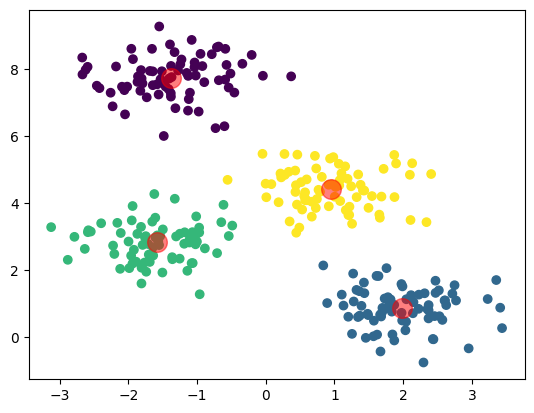

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Generamos un conjunto de datos de muestra
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# Creamos el objeto KMeans
kmeans = KMeans(n_clusters=4, n_init=10)

# Ajustamos el modelo a los datos
kmeans.fit(X)

# Obtenemos las etiquetas de los clusters y los centros de los clusters
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# Graficamos los datos y los centros de los clusters
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)
plt.show()
